**Prompt**

You are an applied physicist at PrecisionS&C, a company specializing in the manufacture of two primary product lines:

- Power supplies capable of generating alternating current (AC) at precisely defined, constant frequencies up to a maximum of 100 Hz.
- Inductor coils with nominal inductances of 6 H, 3 H, 2 H, 1.5 H, 1.2 H, and 1 H.

To ensure that only compliant and high-performance equipment is delivered to customers, randomly selected power supplies are subjected to a quality control testing prior to shipment.

The testing protocol is defined as follows: A reference power supply, calibrated to deliver an AC current at exactly 100 Hz, is connected to an oscilloscope in parallel with the unit under evaluation with frequency of maximum 100 Hz. The phase relationship between the two signals is adjusted until a closed Lissajous figure is observed on the oscilloscope. A power supply is classified as faulty if it cannot be paired with any single inductor coil manufactured by PrecisionS&C to achieve a total inductor impedance of magnitude of 377 ohm rounded to three significant figures - i.e. the computed value has to be in range [376.50; 377.5) ohm interval. Any tested unit identified as faulty must be documented in the quality assurance form. Units which were not tested don't have measurement ID and are assumed not to be faulty.

The attached .zip archive contains table summarizing all measurements conducted during the specified time period, measured Lissajous figures images, with filenames matched to measurement IDs in the table, and quality assurance form.

Using the information provided in this prompt and the attached .zip file, please submit the following three deliverables as downloadable files:

1) A PDF version of the completed quality assurance form, containing one entry for each faulty power supply.
2) A professionally formatted .png file displaying the histogram of daily faulty units.
3) A plain-text (.txt) file listing all production machines with a failure rate exceeding 10% (based on the presented randomly sampled measurements) during the analyzed period.

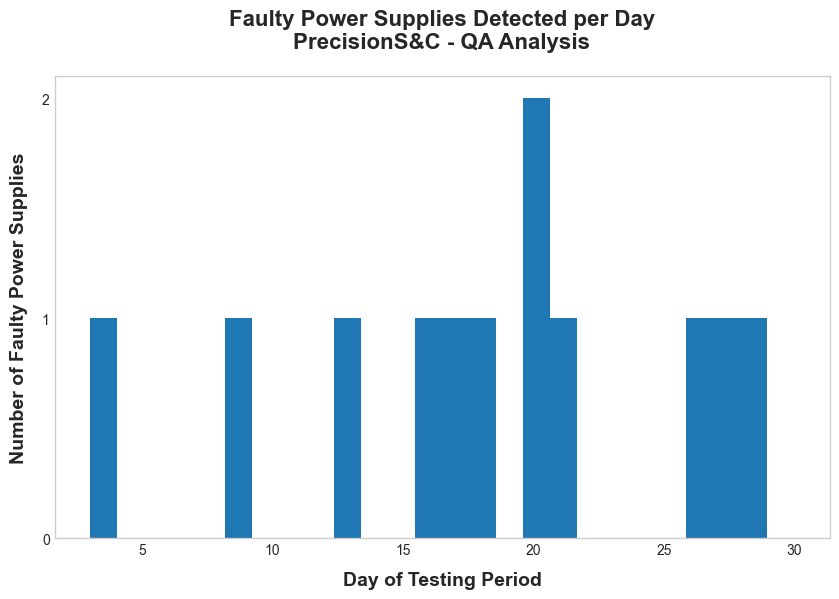

      day  machine supply_ID  failure batch  frequency  reference_frequency  \
36      1    RSTv3  37066178        0     G         50                  100   
1110    1    RSTv3  78641112        0     G         30                  100   
1107    1      98u  11174946        0     C         30                  100   
1127    1      98u  32093387        1     K         80                  100   
531     1  BNPQF53  09911572        0     D         50                  100   
...   ...      ...       ...      ...   ...        ...                  ...   
1629    2   SPN98i  20657221        0     G         30                  100   
83      2  BNPQF53  88654578        0     K         40                  100   
1514    2      98u  44668265        0     D         60                  100   
122     2   SPN98i  93499980        0     A         50                  100   
1902    2  BNPQF53  94974666        1     J         90                  100   

      phase_shift        a1        a2 measurement_i

In [78]:
import numpy as np
import random
import pandas as pd
import string
import matplotlib.pyplot as plt
import os
import shutil

random.seed(42)
number_of_units = 2000
number_of_measurements = 50
df = pd.DataFrame({'day' : pd.Series(dtype='int'),
                    'machine' : pd.Series(dtype='str'),
                    'supply_ID' : pd.Series(dtype='str'),
                    'failure' : pd.Series(dtype='int'),
                    'batch' : pd.Series(dtype='str'),
                    'frequency' : pd.Series(dtype='int'),
                    'reference_frequency' : pd.Series(dtype='int'),
                    'phase_shift' :pd.Series(dtype='float'),
                    'a1' :pd.Series(dtype='int'),
                    'a2' : pd.Series(dtype='int'),
                    'measurement_id' : pd.Series(dtype='str')})
machines_failure = {"BNPQF53": 0.05,
                    "SPN98i" : 0.02,
                    "RSTv3" : 0.01,
                    "720i" : 0.70,
                    "3434tt" : 0.01,
                    "98u" : 0.4
                    }
batches = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L" ]
frequency_phaseshift = {"10": np.pi,
                        "20": np.pi/4,
                        "30": np.pi/4,
                        "40": np.pi/3,
                        "50": np.pi/3,
                        "60": np.pi/4,
                        "70": np.pi/3,
                        "80": np.pi/3,
                        "90": np.pi/3,
                        "100":np.pi/2
                        }

path = "/Users/ondra/Outlier/SpideyMM_project/power_sources/input_data"
os.chdir(path)
folder = 'oscilloscope_output'
shutil.rmtree(folder)
os.makedirs(folder)
number_of_days = 30

for measurement in range(number_of_units):
    day = random.randint(1, number_of_days)
    reference_frequency = 100
    machine = random.choice(list(machines_failure.keys()))
    failure = (random.uniform(0,1) < machines_failure[machine])
    measured = (random.uniform(0,1) < number_of_measurements/number_of_units)
    batch = random.choice(batches)
    supply_id = ''.join(random.choices(string.digits, k=8))

    #TODO Check this, but it should be that all frequencies above 60 Hz should be faulty
    if failure:
        valid_keys = [k for k in frequency_phaseshift.keys() if int(k) > 61]
        frequency = int(random.choice(valid_keys))
    else:
        valid_keys = [k for k in frequency_phaseshift.keys() if int(k) < 61]
        frequency = int(random.choice(valid_keys))
    phase_shift = frequency_phaseshift[str(frequency)]
    a1 = random.uniform(3, 5)
    a2 = random.uniform(3, 5)
    if measured:
        measurement_id = ''.join(random.choices(string.ascii_letters + string.digits, k=9))
        # Time array
        t = np.linspace(0, 2 * np.pi, 10000)

        # Parametric equations
        x = a1 * np.sin(reference_frequency * t + phase_shift)
        y = a2 * np.sin(frequency * t)

        # Plot
        plt.figure(figsize=(10, 10))
        plt.axis([-5, 5, -5, 5])
        plt.plot(x, y)
        plt.grid(True)
        plt.savefig(f"{folder}/ID_{measurement_id}.png")
        plt.close()
    else:
        measurement_id = ""

    new_row = pd.DataFrame([{'day' : day,
                             'supply_ID' : supply_id,
                             'machine' : machine,
                             'failure' : failure,
                             'measured' : measured,
                             'batch' : batch,
                             'frequency' : frequency,
                             'reference_frequency' : reference_frequency,
                             'phase_shift' : phase_shift,
                             'a1' : a1,
                             'a2' : a2,
                             'measurement_id' : measurement_id}])
    df = pd.concat([df, new_row], ignore_index=True)

plt.figure(figsize=(10, 6))
plt.yticks(np.arange(0, 4, 1))
plt.xticks(np.arange(0, number_of_days+1, 5))
df_filtered = df[df['measured'] == 1]
plt.hist(df_filtered['day'], bins=df_filtered['day'].nunique(), weights=df_filtered['failure'])
plt.xlabel('Day of Testing Period', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Number of Faulty Power Supplies', fontsize=14, fontweight='bold', labelpad=10)
plt.title('Faulty Power Supplies Detected per Day\nPrecisionS&C - QA Analysis',
             fontsize=16, fontweight='bold', pad=20)
plt.grid(False)
plt.savefig(f'../golden_solution/histogram.png')
plt.show()


#TODO Print machines with failure above 10%
print(df.sort_values("day").head(100))
df.sort_values("day")[['day', 'supply_ID', 'machine', 'batch', 'measurement_id']].to_csv("measurements.csv", index=False)

failure_rate = df[df["measured"] == 1].groupby('machine').agg(
    failures=('failure', 'sum'),
    total=('failure', 'count')
).reset_index()

filtered_rows = df[(df["measured"] == 1) & (df["frequency"] > 60)]
filtered_rows[["supply_ID", "machine" ,"batch", "frequency"]].to_csv("../golden_solution/table_for_QA.csv", index=False)
print(filtered_rows[["supply_ID", "machine" ,"batch", "frequency"]])

failure_rate['failure_rate'] = failure_rate['failures'] / failure_rate['total']
# Filter machines with failure rate > 10%
high_failure = failure_rate[failure_rate['failure_rate'] > 0.1]
high_failure[['machine']].to_csv('../golden_solution/faulty_machines_over_10percent.txt', index=False, header=False)
print(high_failure)